In [1]:
from pydantic import Field,BaseModel
from typing import List,Optional,Literal
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_PROJECT']='data-analysis-agent-testing'

python-dotenv could not parse statement starting at line 1


In [2]:
from typing import TypedDict,Annotated
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_core.messages import SystemMessage,BaseMessage,HumanMessage,ToolMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.tools import tool
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

class schema_for_subgraph_schema_generator(TypedDict):
    csv_schema:str
    messages:Annotated[List[BaseMessage],add_messages]

In [3]:
@tool
def run_pandas_queries(
    queries: str = Field(..., description="Multiple pandas queries separated by newlines (\\n). Each line should be a valid Python statement. Assign intermediate results to named variables for retrieval."),
    variables_to_return: List[str] = Field(..., description="List of variable names defined in the queries whose values should be returned. Variables not found in scope will return None.")
) -> dict:
    """
    Executes a multi-line pandas query string in an isolated scope and returns
    the values of specified intermediate variables.

    This tool is designed for stepwise data exploration — you can chain multiple
    pandas operations across lines and selectively retrieve any named variable
    from the execution scope.

    Args:
        queries (str): A newline-separated string of valid Python/pandas statements.
                       Variables assigned in earlier lines are accessible in later lines.

        variables_to_return (List[str]): Names of variables from the query scope to
                                         include in the response. Any name not found
                                         in scope will be returned as None.

    Returns:
        dict: On success — {"status": "success", "<var1>": <value>, "<var2>": <value>, ...}
              On failure — {"status": "failed", "error": "<error message>"}

    Eg:
        Input:
            queries = \"\"\"
                import pandas as pd
                df = pd.read_csv('iris.csv')
                columns = df.columns
                shape = df.shape
            \"\"\"
            variables_to_return = ['columns', 'shape']

        Output:
            {
                'status': 'success',
                'columns': Index(['Id', 'SepalLengthCm', ...], dtype='object'),
                'shape': (150, 6)
            }
    """
    try:
        scope = {}
        exec(queries, {}, scope)
        result = {"status": "success"}
        for var in variables_to_return:
            result[var] = scope.get(var, None)
        return result
    except Exception as e:
        return {"status": "failed", "error": str(e)}

In [4]:
[1,2,*[2,2]]

[1, 2, 2, 2]

In [5]:
sys_prompt_for_schema_generator = f"""
You are a data analysis assistant specialized in generating detailed schemas for CSV files.
The schema you produce will be used by downstream pipeline nodes to reference, query, and validate the file.

## Your Task
The user will provide a CSV file path. Use the `run_pandas_queries` tool to thoroughly explore
the file and generate a comprehensive schema based on what you observe — never guess or assume.

## What to Capture
Explore the file sufficiently to document the following:

### File-Level Metadata
- total rows, total columns, duplicate row count

### Per-Column Details
For every column in the file, document:
- **Column name**: exact name as it appears in the file
- **Data type**: pandas dtype (e.g., int64, float64, object, datetime64)
- **Semantic type**: what the column likely represents (e.g., identifier, timestamp, categorical, numeric metric)
- **Sample values**: 3–5 representative values
- **Null count & percentage**: how much data is missing
- **Unique value count**: number of distinct values
- **Range or categories**: min/max for numeric columns; top categories for object columns
- **Description**: Description about data

## Rules
- Run as many `run_pandas_queries` calls as needed — do not stop until all columns are fully documented.
- Always derive every value from tool output — never fabricate or estimate.
- If the file cannot be read, report the error in the schema's error field and stop.
- Do not include any commentary outside the required output format.
"""

def schema_generator(state:schema_for_subgraph_schema_generator):
    
    pr=[SystemMessage(content=sys_prompt_for_schema_generator),*state['messages']]
    res=model_for_schema_generator.invoke(pr)
    
    return {"messages":[res]}

In [6]:
class schema_for_schema_formatter(BaseModel):
    schema_:str

parser_for_schema_formatter=PydanticOutputParser(pydantic_object=schema_for_schema_formatter)

sys_prompt_for_schema_formatter=f"user will give you the output of an ai assistant your task is to covert it into following Output format - {parser_for_schema_formatter.get_format_instructions()}"

def schema_formatter(state:schema_for_subgraph_schema_generator):
    pr=[SystemMessage(content=sys_prompt_for_schema_formatter),HumanMessage(content=state['messages'][-1].content)]
    res=model_for_schema_formatter.invoke(pr)
    res=parser_for_schema_formatter.invoke(res.content)

    return {'csv_schema':res.schema_}

In [7]:
model_for_schema_generator=ChatNVIDIA(model="mistralai/mistral-small-4-119b-2603",max_completion_tokens=10000).bind_tools([run_pandas_queries])
model_for_schema_formatter=ChatNVIDIA(model="mistralai/mistral-small-4-119b-2603",max_completion_tokens=10000)

C:\Users\panka\genai_project\data_analysis_agent\daa\Lib\site-packages\langchain_nvidia_ai_endpoints\_common.py:243: UserWarning: Found mistralai/mistral-small-4-119b-2603 in available_models, but type is unknown and inference may fail.
  warnings.warn(
C:\Users\panka\genai_project\data_analysis_agent\daa\Lib\site-packages\langchain_nvidia_ai_endpoints\chat_models.py:1091: UserWarning: Model 'mistralai/mistral-small-4-119b-2603' is not known to support tools. Your tool binding may fail at inference time.
  warnings.warn(


In [8]:
def tool_call_condition(state:schema_for_subgraph_schema_generator)->Literal['tools','schema_formatter']:
    if state['messages'][-1].tool_calls:
        return 'tools'
    return 'schema_formatter'

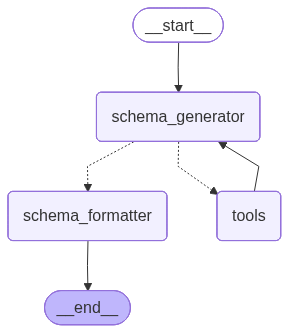

In [9]:
graph=StateGraph(schema_for_subgraph_schema_generator)

graph.add_node('schema_generator',schema_generator)
graph.add_node('schema_formatter',schema_formatter)
graph.add_node('tools',ToolNode(tools=[run_pandas_queries]))

graph.add_edge(START,'schema_generator')
graph.add_conditional_edges('schema_generator',tool_call_condition)

graph.add_edge('tools','schema_generator')
graph.add_edge('schema_formatter',END)

check_ptr=InMemorySaver()
workflow=graph.compile(checkpointer=check_ptr)
workflow

In [10]:
config={"configurable":{'thread_id':'2'}}
res=workflow.invoke({'messages':[HumanMessage(content='File path = ./data/Iris.csv')]},config=config)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [11]:
print(res['csv_schema'])

{
  "file_metadata": {
    "total_rows": 150,
    "total_columns": 6,
    "duplicate_row_count": 0
  },
  "column_metadata": [
    {
      "column_name": "Id",
      "data_type": "int64",
      "semantic_type": "identifier",
      "sample_values": [1, 2, 3],
      "null_count": 0,
      "null_percentage": 0.0,
      "unique_value_count": 150,
      "range": {
        "min": 1,
        "max": 150
      },
      "description": "Unique identifier for each row in the dataset."
    },
    {
      "column_name": "SepalLengthCm",
      "data_type": "float64",
      "semantic_type": "numeric metric",
      "sample_values": [5.1, 4.9, 4.7],
      "null_count": 0,
      "null_percentage": 0.0,
      "unique_value_count": 35,
      "range": {
        "min": 4.3,
        "max": 7.9
      },
      "description": "Sepal length of the iris flower in centimeters."
    },
    {
      "column_name": "SepalWidthCm",
      "data_type": "float64",
      "semantic_type": "numeric metric",
      "sample_valu

In [22]:
class schema_for_pandas_query_generator(BaseModel):
    queries_description:List[str]=Field(...,description='list of queries description')
    
parser_for_pandas_query_generator=PydanticOutputParser(pydantic_object=schema_for_pandas_query_generator)

class schema_for_graph_query_generator_util(BaseModel):
    queries_description:str=Field(...,description='querie description')
    image_name:str=Field(...,description='Name of the file for chart/graph should be a png file')
    
class schema_for_graph_query_generator(BaseModel):
    queries_description:List[schema_for_graph_query_generator_util]
    
parser_for_graph_query_generator=PydanticOutputParser(pydantic_object=schema_for_graph_query_generator)

In [23]:
class schema_for_main_graph(TypedDict):
    file_path:str
    pandas_queries:List[schema_for_pandas_query_generator]
    graph_queries:List[schema_for_graph_query_generator]
    csv_schema=str

In [24]:
sys_prompt_for_pandas_query_generator = f"""
You are a senior data analyst specializing in statistical analysis using Python and pandas.

The user will provide a description of a CSV file. Your task is to generate descriptions of all pandas queries required to produce a comprehensive statistical analysis report of the data.

STRICT RULES:
1. Generate ONLY statistical queries — descriptive stats, distributions, correlations, aggregations, value counts, missing value analysis, outlier detection, and group-by summaries.
2. Use ONLY pandas (and numpy where necessary). No matplotlib, seaborn, plotly, or any visualization libraries.
3. Do NOT write actual code. Write clear, precise natural-language DESCRIPTIONS of each query.
4. These query descriptions will be consumed by another LLM in the next step to write the actual pandas code — so be explicit and unambiguous. Each description must be self-contained and implementation-ready.
5. Every description must specify: the operation type, the column(s) involved, and the expected output shape/format.

Output format:
{parser_for_pandas_query_generator.get_format_instructions()}
"""
def pandas_query_generator(state:schema_for_main_graph):
    pr=[SystemMessage(content=sys_prompt_for_pandas_query_generator),HumanMessage(content=f'Csv description - {state["csv_schema"]}')]

    res=model_for_query_generator.invoke(pr)
    res=parser_for_pandas_query_generator.invoke(res.content)

    return {'pandas_queries':res}

In [25]:
sys_prompt_for_graph_query_generator = f"""
You are a senior data analyst and data visualization expert specializing in exploratory data analysis (EDA).

The user will provide a description of a CSV file. Your task is to generate descriptions of all charts and graphs required to produce a comprehensive, visually rich data analysis report.

STRICT RULES:
1. Generate ONLY visualization queries — distribution plots, correlation heatmaps, bar charts, line charts, scatter plots, box plots, pair plots, pie charts, time series plots, etc.
2. Use ONLY plotly (plotly.express or plotly.graph_objects). Do NOT include any statistical computations or pandas aggregation logic.
3. Do NOT write actual code. Write clear, precise natural-language DESCRIPTIONS of each chart.
4. These chart descriptions will be consumed by another LLM in the next step to write the actual plotly code — so be explicit and unambiguous. Each description must be self-contained and implementation-ready.
5. Every description must specify:
   - Chart type and the preferred plotly module (px vs go) — e.g., "plotly.express scatter", "plotly.graph_objects Heatmap"
   - Column(s) involved (x-axis, y-axis, color/grouping if any)
   - The analytical insight this chart is meant to reveal
   - Any grouping, filtering, or sorting that should be applied before plotting

Output format:
{parser_for_graph_query_generator.get_format_instructions()}
"""
def graph_query_generator(state:schema_for_main_graph):
    pr=[SystemMessage(content=sys_prompt_for_graph_query_generator),HumanMessage(content=f'Csv description - {state["csv_schema"]}')]

    res=model_for_query_generator.invoke(pr)
    res=parser_for_graph_query_generator.invoke(res.content)

    return {'graph_queries':res}

In [26]:
model_for_query_generator=ChatNVIDIA(model="mistralai/mistral-small-4-119b-2603",max_completion_tokens=10000)

In [27]:
x=pandas_query_generator({'csv_schema':res['csv_schema']})
y=graph_query_generator({'csv_schema':res['csv_schema']})

In [28]:
x['pandas_queries']

schema_for_pandas_query_generator(queries_description=['Calculate basic descriptive statistics (mean, median, std, min, max, quartiles) for all numeric columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm). Output should be a pandas DataFrame with 5 rows (statistic names) and 4 columns (numeric features).', "Count the frequency of each category in the 'Species' column and calculate the percentage of each category relative to the total count. Output should be a pandas Series with index as the unique 'Species' values and columns as count and percentage.", 'Check for missing values in all columns by summing the count of null values per column. Output should be a pandas Series with column names as index and null counts as values.', 'Calculate the interquartile range (IQR) for the numeric columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm) to understand the spread of the middle 50% of the data. Output should be a pandas DataFrame with 4 rows (one per numeric feat

In [29]:
y['graph_queries']

schema_for_graph_query_generator(queries_description=[schema_for_graph_query_generator_util(queries_description="Use plotly.express histogram to create a distribution plot of the 'SepalLengthCm' column. This chart should reveal the frequency distribution of sepal lengths across all iris flowers. The x-axis should represent 'SepalLengthCm', the y-axis should show the count of observations, and the color should encode the 'Species' to differentiate distributions by species. Group the data by 'Species' and sort the bins by 'SepalLengthCm' in ascending order for clarity.", image_name='distribution_sepal_length.png'), schema_for_graph_query_generator_util(queries_description="Use plotly.express histogram to create a distribution plot of the 'SepalWidthCm' column. This chart should reveal the frequency distribution of sepal widths across all iris flowers. The x-axis should represent 'SepalWidthCm', the y-axis should show the count of observations, and the color should encode the 'Species' to

In [34]:
# sub_graph_for_pandas_query
class schema_for_pandas_query_formatter(BaseModel):
    query:str=Field(...,description='query')
    result:str=Field(...,description='result')
    
class schema_for_pandas_query_executor(TypedDict):
    csv_schema:str
    messages:Annotated[BaseMessage,add_messages]
    query:str
    formatted_result:schema_for_pandas_query_formatter

In [67]:

sys_prompt_for_pandas_query_executor="""
You are an data analyst . User will provide you a task and a csv schema Your task is to write and execute a single line/multi line pandas queries to acheive the desired output.
"""

def chat_node_for_pandas_query_executor(state:schema_for_pandas_query_executor):
    pr=None
    if len(state['messages'])==0:
        p=HumanMessage(content=f"csv_schema: {state['csv_schema']} \n\n task:{state['query']}")
        pr=[SystemMessage(content=sys_prompt_for_pandas_query_executor),p]
    else:
        pr=[SystemMessage(content=sys_prompt_for_pandas_query_executor),*state['messages']]
        
    print(pr)
    res=model_for_query_executor.invoke(pr)

    return {'messages':[res]}

In [68]:
sys_prompt_for_pandas_query_formatter=f"""
User will provide you an query and the answer generated by user for the given query your task is to format it into given format -
"""

def pandas_query_formator(state:schema_for_pandas_query_executor):
    pr=[SystemMessage(content=sys_prompt_for_pandas_query_formatter),HumanMessage(content=f"""
    query - {state['query']} 
    result - {state['messages'][-1].content}
    """)]

    res=model_for_query_executor.invoke(pr)
    res=pandas_query_formator.invoke(res.content)
    return {'formatted_result':res}

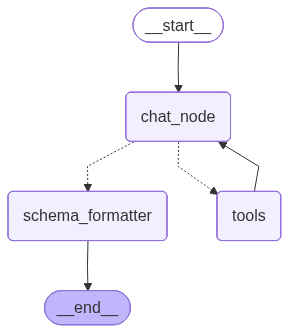

In [63]:
graph=StateGraph(schema_for_pandas_query_executor)

graph.add_node('chat_node',chat_node_for_pandas_query_executor)
graph.add_node('schema_formatter',pandas_query_formator)
graph.add_node('tools',ToolNode([run_pandas_queries]))

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tool_call_condition)
graph.add_edge('tools','chat_node')

workflow=graph.compile(checkpointer=check_ptr)
workflow

In [64]:
x['pandas_queries'].queries_description[0]

'Calculate basic descriptive statistics (mean, median, std, min, max, quartiles) for all numeric columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm). Output should be a pandas DataFrame with 5 rows (statistic names) and 4 columns (numeric features).'

In [65]:
model_for_query_executor=ChatNVIDIA(model="mistralai/mistral-small-4-119b-2603",max_completion_tokens=10000).bind_tools([run_pandas_queries])

In [69]:
res['csv_schema']

'{\n  "file_metadata": {\n    "total_rows": 150,\n    "total_columns": 6,\n    "duplicate_row_count": 0\n  },\n  "column_metadata": [\n    {\n      "column_name": "Id",\n      "data_type": "int64",\n      "semantic_type": "identifier",\n      "sample_values": [1, 2, 3],\n      "null_count": 0,\n      "null_percentage": 0.0,\n      "unique_value_count": 150,\n      "range": {\n        "min": 1,\n        "max": 150\n      },\n      "description": "Unique identifier for each row in the dataset."\n    },\n    {\n      "column_name": "SepalLengthCm",\n      "data_type": "float64",\n      "semantic_type": "numeric metric",\n      "sample_values": [5.1, 4.9, 4.7],\n      "null_count": 0,\n      "null_percentage": 0.0,\n      "unique_value_count": 35,\n      "range": {\n        "min": 4.3,\n        "max": 7.9\n      },\n      "description": "Sepal length of the iris flower in centimeters."\n    },\n    {\n      "column_name": "SepalWidthCm",\n      "data_type": "float64",\n      "semantic_type

In [70]:
a=workflow.invoke({'csv_schema':res['csv_schema'],'query':x['pandas_queries'].queries_description[0]},config=config)

[SystemMessage(content='\nYou are an data analyst . User will provide you a task and a csv schema Your task is to write single line/multi line pandas queries to acheive the desired output.\n', additional_kwargs={}, response_metadata={}), HumanMessage(content='File path = ./data/Iris.csv', additional_kwargs={}, response_metadata={}, id='672552ae-e6f9-466b-ad5c-19ab6308386b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8aPuclmrw', 'type': 'function', 'function': {'name': 'run_pandas_queries', 'arguments': '{"queries": "import pandas as pd\\n\\ndf = pd.read_csv(\'./data/Iris.csv\')\\nfile_shape = df.shape\\nfile_columns = df.columns", "variables_to_return": ["df", "file_shape", "file_columns"]}'}}]}, response_metadata={'role': 'assistant', 'content': None, 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': '8aPuclmrw', 'type': 'function', 'function': {'name': 'run_pandas_queries', 'arguments': '{"queries": "import pandas 

Exception: [400] {'message': 'Cannot set `add_generation_prompt` to True when the last message is from the assistant. Consider using `continue_final_message` instead.', 'type': 'BadRequestError', 'param': None, 'code': 400}
{'error': {'message': 'Cannot set `add_generation_prompt` to True when the last message is from the assistant. Consider using `continue_final_message` instead.', 'type': 'BadRequestError', 'param': None, 'code': 400}, 'status': 400}